**DIAMOND A-DC PBSHM Coding Challenge**

---

- **Name**: Ernest Toochukwu, Samuel
- **Date**: 02-04-2026

---
# Task 2 - Simple structure-level baseline
Build a simple baseline for damage detection using fixed-length summaries of each structure.

Examples include:

- logistic regression
- Random forest
- support vector machine
- A small MLP
Because structures have different numbers of nodes, you will need to design a sensible summary representation.

Report appropriate metrics such as accuracy, F1, and ROC-AUC using cross-validation.

In [1]:
# %pip install -U matplotlib seaborn


In [2]:
"""
Importing necessary libraries and setting up the environment
for data analysis and visualization.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import KFold


plt.style.use('seaborn-v0_8')

In [3]:
# # Uncomment if you are running on Google Colab and need to mount your Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

## Functions Definitions

**Script Functions Summary**

- `normalize_structure_features`: Normalizes frequency and height-related features for structures.

- `run_cv_and_report`: Trains model and Performs stratified K-fold cross-validation, reports metrics, and identifies the best model.

- `plot_model_comparison`: Generates a comparison plot of model performance metrics (Accuracy, F1 Score, ROC-AUC).

In [4]:

# Feature Normalization Funtion
def normalize_structure_features(structure_df_to_normalize):
    """
    Normalizes specified frequency and height related features in a DataFrame
    and returns a new DataFrame with normalized values and original labels.

    Args:
        structure_df_to_normalize (pd.DataFrame): The input DataFrame containing
                                                  'frequency_Hz_squared_std',
                                                  'frequency_std_times_total_height',
                                                  'damaged', and 'structure_id' columns.

    Returns:
        pd.DataFrame: A new DataFrame with 'Freq_norm', 'Height_norm',
                      'damaged', and 'structure_id' columns.
    """

    # 1. Initialize the MinMaxScaler
    scaler = MinMaxScaler()

    # 2. Select the columns to be normalized
    cols_to_normalize = ['frequency_Hz_squared_std', 'frequency_std_times_total_height']

    # 3. Apply the transformation
    normalized_data = scaler.fit_transform(structure_df_to_normalize[cols_to_normalize])

    # 4. Create the final dataframe with your requested names
    # We create new columns for normalized values and pull the rest from the original
    structure_norm_df = pd.DataFrame(normalized_data, columns=['Freq_norm', 'Height_norm'], index=structure_df_to_normalize.index)

    # Add the remaining original columns
    structure_norm_df['damaged'] = structure_df_to_normalize['damaged']
    structure_norm_df['structure_id'] = structure_df_to_normalize['structure_id']

    return structure_norm_df


# Base-Line Model Training, Cross-Validation and Reporting Function
def run_cv_and_report(features, target_damaged, estimator_class, estimator_params=None, n_splits=3, random_state=50, epochs=200):
    """
    Trains baseline model and performs stratified K-fold cross-validation, reports metrics per fold,
    and identifies the best performing model.

    Args:
        features (pd.DataFrame): Feature matrix.
        target_damaged (pd.Series): Target vector.
        estimator_class (class): The scikit-learn model (e.g., RandomForestClassifier, LogisticRegression).
        estimator_params (dict, optional): Dictionary of parameters for the estimator. Defaults to None.
        n_splits (int, optional): Number of folds for cross-validation. Defaults to 3.
        random_state (int, optional): Random state for reproducibility. Defaults to 50.
        epochs (int, optional): Interpreted as n_estimators for RandomForest or max_iter for LogisticRegression.
                                A true 'attention stop' based on validation performance during iterative training
                                is not directly supported by these scikit-learn estimators in this setup.
                                The model will fit once per fold. Defaults to 200.

    Returns:
        tuple: (best_model, all_fold_results)
               best_model (estimator): The trained model instance that achieved the highest ROC-AUC on its
                                       validation fold.
               all_fold_results (pd.DataFrame): DataFrame containing metrics for each fold.
    """
    if estimator_params is None:
        estimator_params = {}

    # Adapt 'epochs' to estimator-specific parameters
    if estimator_class == RandomForestClassifier:
        estimator_params['n_estimators'] = epochs
    elif estimator_class == LogisticRegression:
        estimator_params['max_iter'] = epochs

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_results = []
    best_roc_auc = -1
    best_model = None
    best_fold_number = -1

    print(f"Starting Cross-Validation for {estimator_class.__name__}...")
    for fold, (train_index, val_index) in enumerate(cv.split(features, target_damaged)):
        X_train, X_val = features.iloc[train_index], features.iloc[val_index]
        y_train, y_val = target_damaged.iloc[train_index], target_damaged.iloc[val_index]

        # Initialize a new estimator for each fold
        model = estimator_class(**estimator_params)

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities and labels on the validation set
        y_val_pred_proba = model.predict_proba(X_val)[:, 1]
        y_val_pred = model.predict(X_val)

        # Calculate metrics
        accuracy = accuracy_score(y_val, y_val_pred)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)
        try:
            roc_auc = roc_auc_score(y_val, y_val_pred_proba)
        except ValueError: # Handle cases where only one class is present in y_val
            roc_auc = np.nan

        fold_results.append({
            'fold': fold + 1,
            'accuracy': accuracy,
            'f1_score': f1,
            'roc_auc': roc_auc
        })

        print(f"--- Fold {fold + 1} Report ---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC-AUC: {roc_auc:.4f}")

        # Keep track of the best model based on ROC-AUC
        if not np.isnan(roc_auc) and roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_model = model # Store the trained model instance
            best_fold_number = fold + 1

    all_fold_results_df = pd.DataFrame(fold_results)

    print("\n----------// Cross-Validation Summary //----------")
    print(all_fold_results_df.round(4))
    print("\n----------// Overall Performance //----------")
    print(f"Mean Accuracy: {all_fold_results_df['accuracy'].mean():.4f} +/- {all_fold_results_df['accuracy'].std():.4f}")
    print(f"Mean F1 Score: {all_fold_results_df['f1_score'].mean():.4f} +/- {all_fold_results_df['f1_score'].std():.4f}")
    print(f"Mean ROC-AUC: {all_fold_results_df['roc_auc'].mean():.4f} +/- {all_fold_results_df['roc_auc'].std():.4f}")

    if best_model:
        print(f"\nBest Model found in Fold {best_fold_number} (with ROC-AUC: {best_roc_auc:.4f}):")
        print(best_model)
    else:
        print("\nNo best model identified (e.g., all ROC-AUCs were NaN).")

    return best_model, all_fold_results_df


# Model Comparison Plotting Function
def plot_model_comparison(rf_fold_results, lr_fold_results):
    """
    Generates and displays a comparison plot of model performance metrics.

    Args:
        rf_fold_results (pd.DataFrame): DataFrame containing cross-validation results for Random Forest.
        lr_fold_results (pd.DataFrame): DataFrame containing cross-validation results for Logistic Regression.
    """
    metrics_data = {
        'Model': ['Random Forest', 'Logistic Regression'],
        'Mean Accuracy': [rf_fold_results['accuracy'].mean(), lr_fold_results['accuracy'].mean()],
        'Std Accuracy': [rf_fold_results['accuracy'].std(), lr_fold_results['accuracy'].std()],
        'Mean F1 Score': [rf_fold_results['f1_score'].mean(), lr_fold_results['f1_score'].mean()],
        'Std F1 Score': [rf_fold_results['f1_score'].std(), lr_fold_results['f1_score'].std()],
        'Mean ROC-AUC': [rf_fold_results['roc_auc'].mean(), lr_fold_results['roc_auc'].mean()],
        'Std ROC-AUC': [lr_fold_results['roc_auc'].std(), lr_fold_results['roc_auc'].std()]
    }

    summary_df = pd.DataFrame(metrics_data)

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', color='black')

    metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
    for i, metric in enumerate(metrics):
        mean_col = f'Mean {metric}'
        std_col = f'Std {metric}'

        sns.barplot(x='Model', y=mean_col, data=summary_df, ax=axes[i], palette='viridis', hue='Model', legend=False)

      
        # Add best score to the title per model
        rf_score = summary_df.loc[summary_df['Model'] == 'Random Forest', mean_col].iloc[0]
        lr_score = summary_df.loc[summary_df['Model'] == 'Logistic Regression', mean_col].iloc[0]
        axes[i].set_title(f'{metric} (RF: {rf_score:.2f}, LR: {lr_score:.2f})', fontweight='bold', color='black')
        axes[i].set_ylabel(f'Mean {metric}', fontweight='bold', color='black')
        axes[i].set_xlabel('Model', fontweight='bold', color='black') # Set x-label explicitly
        axes[i].set_ylim(0, 1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



# Data Import and processing
- Import all datafram and variables from Task1

In [5]:
%%capture

# Run and capture all needed variables from Task1
%run task1_explore_population.ipynb

In [6]:
nodes_df.head(1)
structure_df.head(1)

,structure_id,n_storeys,total_height,damaged,frequency_std_times_total_height,frequency_Hz_squared_std,inverse_height_cubed_std,inverse_total_height_cubed
0,0,6,24.905,0,62.890163,23.539426,0.006237,0.000065


In [7]:
structure_df.head()

,structure_id,n_storeys,total_height,damaged,frequency_std_times_total_height,frequency_Hz_squared_std,inverse_height_cubed_std,inverse_total_height_cubed
0,0,6,24.905,0,62.890163,23.539426,0.006237,0.000065
1,1,5,19.219,0,38.811851,22.900213,0.009751,0.000141
2,2,8,32.077,0,37.989516,12.433084,0.008727,0.000030
3,3,6,22.181,1,56.705535,25.117397,0.002201,0.000092
4,4,7,29.248,1,68.461296,25.170422,0.006831,0.000040


In [8]:
#Variable from Task1

# Structure Dataframe for Baseline Modelling
structure_bl_df1 = structure_df[['structure_id', 'damaged', 'frequency_Hz_squared_std', 'frequency_std_times_total_height']]



In [9]:
# selected_structure_correlation_matrix

In [10]:

# Normalize selected structure features
structure_norm_df = normalize_structure_features(structure_bl_df1)
structure_norm_df.head()


,Freq_norm,Height_norm,damaged,structure_id
0,0.861854,0.684679,0,0
1,0.834459,0.313477,0,1
2,0.385878,0.300799,0,2
3,0.929480,0.589334,1,3
4,0.931752,0.770566,1,4


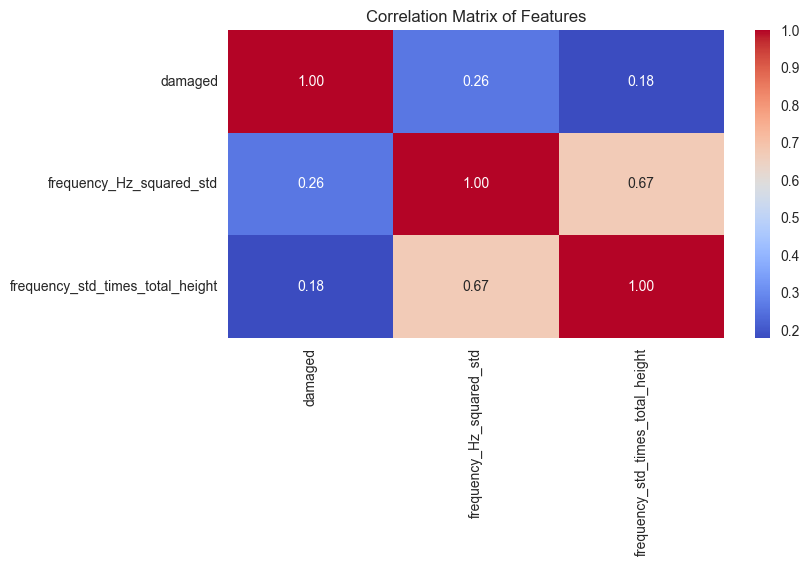

In [11]:
# Compute the correlation matrix without 'structure_id'
correlation_matrix = structure_bl_df1.drop(columns=['structure_id']).corr()

# Plot the heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Features")
plt.show()

# **Baseline Model**

## Random Forest -Baseline Model

In [12]:
# ── Features & Target ─────────────────────────────────────────────
features = structure_norm_df.drop(columns=['structure_id', 'damaged'])
target_damaged = structure_norm_df['damaged']

# ── Random Forest Model ─────────────────────────────────────────────────────────
rf_params = {
    'max_depth': 6,
    'min_samples_leaf': 4,
    'class_weight': 'balanced',
    'random_state': 50
}

best_rf_model, rf_fold_results = run_cv_and_report(
    features,
    target_damaged,
    estimator_class=RandomForestClassifier,
    estimator_params=rf_params,
    n_splits=3,
    random_state=50,
    epochs=100 # n_estimators for RandomForestClassifier
)

# rf is now your best_rf_model for feature importance or further use

Starting Cross-Validation for RandomForestClassifier...
--- Fold 1 Report ---
Accuracy: 0.5882
F1 Score: 0.4615
ROC-AUC: 0.6417
--- Fold 2 Report ---
Accuracy: 0.7647
F1 Score: 0.5000
ROC-AUC: 0.7667
--- Fold 3 Report ---
Accuracy: 0.7500
F1 Score: 0.5000
ROC-AUC: 0.4364

----------// Cross-Validation Summary //----------
   fold  accuracy  f1_score  roc_auc
0     1    0.5882    0.4615   0.6417
1     2    0.7647    0.5000   0.7667
2     3    0.7500    0.5000   0.4364

----------// Overall Performance //----------
Mean Accuracy: 0.7010 +/- 0.0979
Mean F1 Score: 0.4872 +/- 0.0222
Mean ROC-AUC: 0.6149 +/- 0.1668

Best Model found in Fold 2 (with ROC-AUC: 0.7667):
RandomForestClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=4,
                       random_state=50)


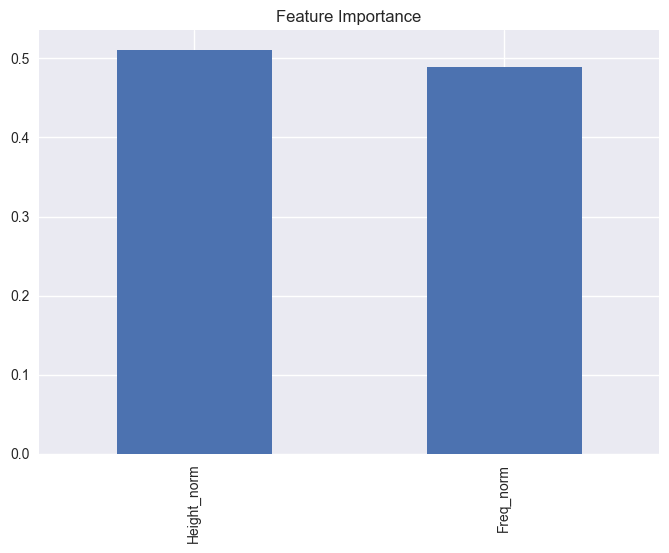

In [13]:
feat_imp = pd.Series(best_rf_model.feature_importances_, index=features.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

## Logistic Regression Baseline Model

In [14]:
# ── Features & Target ─────────────────────────────────────────────
features = structure_norm_df.drop(columns=['structure_id', 'damaged'])
target_damaged = structure_norm_df['damaged']

# ── Logistics regression Model ─────────────────────────────────────────────────────────
lr_params = {
    'class_weight': 'balanced',
    'random_state': 50
}

best_lr_model, lr_fold_results = run_cv_and_report(
    features,
    target_damaged,
    estimator_class=LogisticRegression,
    estimator_params=lr_params,
    n_splits=3,
    random_state=50,
    epochs=1000 # max_iter for LogisticRegression
)

# lr is now your best_lr_model

Starting Cross-Validation for LogisticRegression...
--- Fold 1 Report ---
Accuracy: 0.7059
F1 Score: 0.5455
ROC-AUC: 0.6833
--- Fold 2 Report ---
Accuracy: 0.5294
F1 Score: 0.4286
ROC-AUC: 0.7333
--- Fold 3 Report ---
Accuracy: 0.4375
F1 Score: 0.4000
ROC-AUC: 0.6000

----------// Cross-Validation Summary //----------
   fold  accuracy  f1_score  roc_auc
0     1    0.7059    0.5455   0.6833
1     2    0.5294    0.4286   0.7333
2     3    0.4375    0.4000   0.6000

----------// Overall Performance //----------
Mean Accuracy: 0.5576 +/- 0.1364
Mean F1 Score: 0.4580 +/- 0.0771
Mean ROC-AUC: 0.6722 +/- 0.0674

Best Model found in Fold 2 (with ROC-AUC: 0.7333):
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=50)


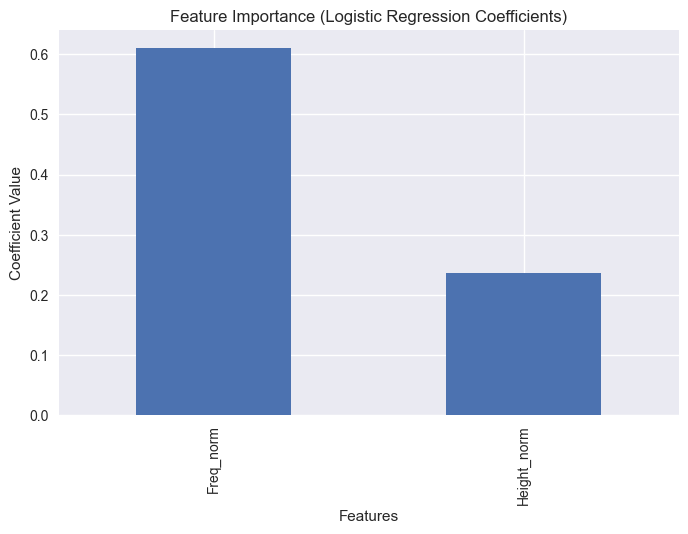

In [15]:
feat_imp = pd.Series(best_lr_model.coef_[0], index=features.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.show()

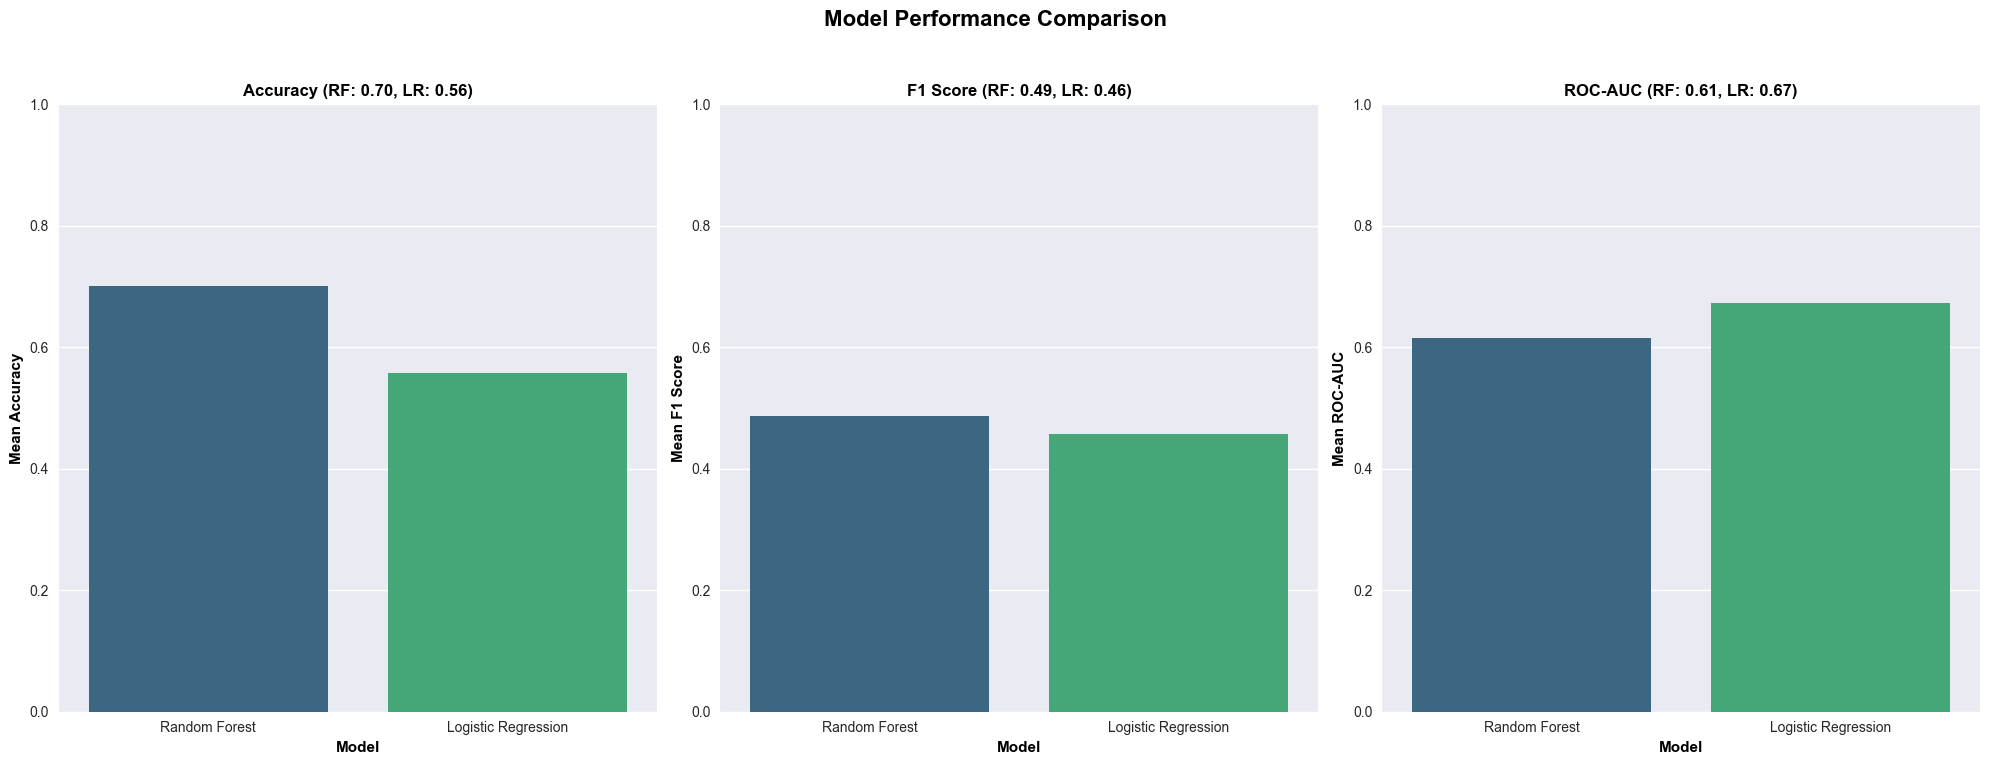

In [16]:
# Call Plot Function to generate Model Performance Summary
plot_model_comparison(rf_fold_results, lr_fold_results)

### Modeling and Performance Evaluation Summary

---

**Random Forest Classifier:**

- **Feature Importance:** The feature importance plot for the Random Forest model indicated that both `Height_norm` and `Freq_norm` contributed significantly to the model's predictions, with `Height_norm` having a slightly higher importance.
---
**Logistic Regression:**

- **Feature Importance:** For Logistic Regression, the coefficients were used as a proxy for feature importance. `Freq_norm` showed a higher coefficient value, suggesting a stronger positive correlation with the damaged status compared to `Height_norm`.



**Baseline Model Comparison Summary**

---

A comparative evaluation was conducted between Random Forest and Logistic Regression using stratified cross-validation.

---

- Overall, Random Forest demonstrated more consistent performance in terms of classification accuracy and F1 score, indicating better handling of class imbalance and nonlinear relationships. However, its ROC-AUC showed higher variance across folds, suggesting some instability in ranking performance.

- Logistic Regression exhibited more stable ROC-AUC scores but underperformed in both accuracy and F1 score, indicating limited capacity to capture complex patterns in the data.

---
**Selected Baseline Model:**

- ***Random Forest***

---
This choice is based on its stronger overall classification performance and better alignment with the problem’s likely nonlinear and structured nature.